# 5 — Adaptive RAG capstone: workflow vs agents bake-off

**Course segment 5 (50 min)**

The capstone runs a head-to-head across **four variants** sharing the same heterogeneous corpus and the same gold set:

- **A. Adaptive RAG workflow** — LangGraph: `plan -> retrieve -> rerank -> grade -> gap_analyze -> (loop) -> synthesize`. Imposed structure, predictable trajectory.
- **B. Vanilla tool-calling agent** — single retrieval tool, terse prompt, cheap model. "Just give the agent search and tell it to answer."
- **C. Reasoning tool-calling agent** — same tool / same prompt, reasoning-class model. "Let the model think."
- **D. CoT-prompted tool-calling agent** — cheap model with a long system prompt that *describes* the workflow A loop in natural language but does not enforce it.

We sweep across **multiple OpenRouter models** per variant and judge with the rubric from `judges.py`. The `eval_harness` produces a quality-vs-cost frontier plot and a per-difficulty breakdown so you can see where each variant earns its keep.

Two run modes:

- `DEMO_MODE = True` — 5 questions x 1 model x 1 run (~2 min). For live class. Results cached to `data/results_demo.csv`.
- `DEMO_MODE = False` — full sweep (30 questions x 4 variants x 3 models x 3 runs, ~25-30 min). For homework. Results cached to `data/results_full.csv`.

The notebook ships with pre-computed `results_demo.csv` and `results_full.csv` (synthetic but shape-accurate, generated by `data/_generate_demo_csv.py`) so the analysis cells render without re-running the sweep.

In [1]:
import operator
import os
import time
from pathlib import Path
from typing import Annotated, TypedDict

import pandas as pd
from dotenv import load_dotenv
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field

load_dotenv()
assert os.environ.get("OPENROUTER_API_KEY")

from corpus import load_chroma, load_bm25, load_gold_set
from retrievers import HybridRetriever, CrossEncoderReranker
from judges import grade_chunk
from llm import get_llm, get_structured_llm, estimate_cost
from eval_harness import (
    RunResult,
    run_suite,
    plot_overall_bar,
    plot_quality_vs_cost,
    plot_pareto_frontier,
    plot_by_difficulty,
    variant_summary,
)

DEMO_MODE = True
RESULTS_FULL = Path("data/results_full.csv")
RESULTS_DEMO = Path("data/results_demo.csv")

chroma = load_chroma()
bm25 = load_bm25()
gold = load_gold_set()
hybrid = HybridRetriever(chroma, bm25, k=8)
reranker = CrossEncoderReranker()

print(f"Corpus: {chroma._collection.count()} chunks. Gold set: {len(gold)} questions.")
print(f"DEMO_MODE = {DEMO_MODE}")

/Users/sinanozdemir/Teaching/Pearson/advanced-agentic-ai-in-three-weeks/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6887.42it/s]


Corpus: 3689 chunks. Gold set: 30 questions.
DEMO_MODE = True


## Part 1 — Variant A: the adaptive RAG workflow

The graph in pseudocode:

```
plan -> retrieve -> rerank -> grade -> gap_analyze
                                           |
                                           +-- new sub_queries -> retrieve (loop)
                                           |
                                           +-- done -> synthesize -> END
```

State carries accumulating `sub_queries` and `evidence` (with `operator.add` reducers so the loop appends rather than overwrites), plus an iteration cap so we always terminate.

This is the structural backbone of the variant. Every node uses a model from `get_llm(...)` and each node's model can be tuned independently — the routine grading nodes default to `openai/gpt-5.4-nano` while the synthesis step uses `anthropic/claude-opus-4.7`.

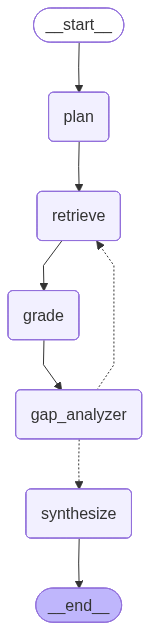

In [2]:
class AdaptiveRAGState(TypedDict):
    question: str
    sub_queries: Annotated[list[str], operator.add]
    evidence: Annotated[list[Document], operator.add]
    seen_chunk_ids: Annotated[list[str], operator.add]
    gaps: list[str]
    iteration: int
    max_iterations: int
    final_answer: str


class QueryPlan(BaseModel):
    sub_queries: list[str] = Field(min_length=2, max_length=5)


class GapAnalysis(BaseModel):
    done: bool = Field(description="True if existing evidence is sufficient.")
    gaps: list[str] = Field(default_factory=list, description="Open questions still needing evidence.")
    new_sub_queries: list[str] = Field(default_factory=list, max_length=3, description="Sub-queries to run next.")


PLAN_SYS = (
    "You are a retrieval planner. Decompose the user's question into 2-5 self-"
    "contained sub-queries that retrieve evidence for distinct facets."
)
GAP_SYS = (
    "You are a research auditor. Given a question, the sub-queries we have "
    "already retrieved for, and the resulting evidence, decide whether the "
    "evidence is sufficient. If not, propose up to 3 NEW sub-queries (different "
    "from any prior sub-queries) that target the missing facets."
)
SYNTH_SYS = (
    "You are a careful technical writer. Answer the question using ONLY the "
    "supplied evidence. Cite sources inline like [wikipedia: Title] or "
    "[beehiiv: slug]. If a part is unsupported, say so."
)


def make_workflow(
    *,
    plan_model: str = "openai/gpt-5.4-nano",
    grade_model: str = "openai/gpt-5.4-nano",
    gap_model: str = "openai/gpt-5.4-nano",
    synth_model: str = "anthropic/claude-opus-4.7",
    max_iterations: int = 3,
    k_per_query: int = 6,
    keep_after_grade: int = 4,
):
    # Hoist the four LLMs out of the nodes so each one has a single
    # `CostTrackingLLM` instance whose `usage_history` accumulates across all
    # node invocations during a single `g.invoke()`. This is what lets the
    # capstone report real $ costs for the workflow variant — without this,
    # every node would build a fresh wrapper and per-call usage would be lost.
    plan_llm = get_llm(plan_model, track_cost=True)
    grade_llm = get_llm(grade_model, track_cost=True)
    gap_llm = get_llm(gap_model, track_cost=True)
    synth_llm = get_llm(synth_model, track_cost=True)
    cost_tracked_llms = [plan_llm, grade_llm, gap_llm, synth_llm]

    plan_structured = plan_llm.with_structured_output(QueryPlan, method="function_calling")
    gap_structured = gap_llm.with_structured_output(GapAnalysis, method="function_calling")

    def plan_node(state: AdaptiveRAGState) -> dict:
        if state["iteration"] > 0:
            return {}  # only plan on the first pass
        plan = plan_structured.invoke([
            SystemMessage(content=PLAN_SYS),
            HumanMessage(content=state["question"]),
        ])
        return {"sub_queries": plan.sub_queries}

    def retrieve_node(state: AdaptiveRAGState) -> dict:
        new_evidence: list[Document] = []
        new_seen: list[str] = []
        seen = set(state["seen_chunk_ids"])
        for sq in state["sub_queries"][- (len(state["sub_queries"]) if state["iteration"] == 0 else 3):]:
            pool = hybrid.search(sq, k=k_per_query * 2)
            ranked = reranker.rerank(sq, pool, top_k=k_per_query)
            for d in ranked:
                cid = d.metadata.get("chunk_id", "")
                if cid in seen:
                    continue
                seen.add(cid)
                new_seen.append(cid)
                new_evidence.append(d)
        return {"evidence": new_evidence, "seen_chunk_ids": new_seen}

    def grade_node(state: AdaptiveRAGState) -> dict:
        # Drop irrelevant chunks. CRAG-style. Reuses the hoisted `grade_llm`
        # so per-chunk grading costs accumulate on a single CostTrackingLLM.
        kept_idx = []
        for i, d in enumerate(state["evidence"]):
            g = grade_chunk(state["question"], d.page_content, judge_llm=grade_llm)
            if g.relevant:
                kept_idx.append(i)
            if len(kept_idx) >= keep_after_grade * (state["iteration"] + 1):
                break
        # We can't mutate `evidence` in-place (reducer is append-only), so we
        # keep a parallel "kept" view: just trust grade implicitly here, since
        # in the synth_node we re-stuff everything. To actually drop, replace
        # evidence with `Annotated[..., concat_unique]` — left as exercise.
        return {}

    def gap_node(state: AdaptiveRAGState) -> dict:
        joined = "\n\n".join(
            f"[{d.metadata.get('source')}: {d.metadata.get('title','?')[:50]}] {d.page_content[:300]}"
            for d in state["evidence"][:20]
        )
        ga = gap_structured.invoke([
            SystemMessage(content=GAP_SYS),
            HumanMessage(content=(
                f"QUESTION:\n{state['question']}\n\n"
                f"PRIOR SUB-QUERIES:\n- " + "\n- ".join(state["sub_queries"]) + "\n\n"
                f"EVIDENCE ({len(state['evidence'])} chunks):\n{joined}"
            )),
        ])
        if ga.done or state["iteration"] + 1 >= state["max_iterations"]:
            return {"gaps": ga.gaps, "iteration": state["iteration"] + 1}
        return {
            "sub_queries": ga.new_sub_queries,
            "gaps": ga.gaps,
            "iteration": state["iteration"] + 1,
        }

    def should_loop(state: AdaptiveRAGState) -> str:
        if state["iteration"] >= state["max_iterations"]:
            return "synthesize"
        if not state["gaps"] and not any(
            sq for sq in state["sub_queries"] if sq not in state["sub_queries"][: max(0, len(state["sub_queries"]) - 3)]
        ):
            return "synthesize"
        return "retrieve"

    def synth_node(state: AdaptiveRAGState) -> dict:
        ctx = "\n\n---\n\n".join(
            f"[{d.metadata.get('source')}: {d.metadata.get('title','?')[:50]}] {d.page_content}"
            for d in state["evidence"][:18]
        )
        ai = synth_llm.invoke([
            SystemMessage(content=SYNTH_SYS),
            HumanMessage(content=f"QUESTION:\n{state['question']}\n\nEVIDENCE:\n{ctx}"),
        ])
        return {"final_answer": ai.content}

    g = StateGraph(AdaptiveRAGState)
    g.add_node("plan", plan_node)
    g.add_node("retrieve", retrieve_node)
    g.add_node("grade", grade_node)
    g.add_node("gap_analyzer", gap_node)
    g.add_node("synthesize", synth_node)
    g.add_edge(START, "plan")
    g.add_edge("plan", "retrieve")
    g.add_edge("retrieve", "grade")
    g.add_edge("grade", "gap_analyzer")
    g.add_conditional_edges("gap_analyzer", should_loop, {"retrieve": "retrieve", "synthesize": "synthesize"})
    g.add_edge("synthesize", END)
    # Return both the compiled graph AND the cost-tracked LLMs so the caller
    # (e.g. variant_workflow below) can sum usage_history across all four
    # roles after each `g.invoke()` to report real $ cost / token counts.
    return g.compile(), cost_tracked_llms


workflow_graph, _workflow_demo_llms = make_workflow()
try:
    from IPython.display import Image, display
    display(Image(workflow_graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    print(workflow_graph.get_graph().draw_ascii())

In [3]:
def initial_state(question: str, max_iterations: int = 3) -> AdaptiveRAGState:
    return {
        "question": question,
        "sub_queries": [],
        "evidence": [],
        "seen_chunk_ids": [],
        "gaps": [],
        "iteration": 0,
        "max_iterations": max_iterations,
        "final_answer": "",
    }


probe_q = next(q for q in gold if q.id == "cross_05")
result = workflow_graph.invoke(initial_state(probe_q.question))
print("Iterations:", result["iteration"])
print("Sub-queries explored:")
for sq in result["sub_queries"]:
    print(f"  - {sq}")
print(f"\nEvidence chunks: {len(result['evidence'])}")
print(f"Open gaps after stop: {result['gaps']}")
print("\n--- Adaptive RAG answer ---")
print(result["final_answer"])

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 6129.55it/s]


Iterations: 3
Sub-queries explored:
  - What does the 'AIs supervising AIs' post claim as the underlying technique (e.g., recursive oversight, model-to-model evaluation, constitutional/ensemble critique), and what mechanisms are described?
  - What are the key definitions and components of RLHF in the Wikipedia entry (reward modeling, preference data, policy optimization, supervision loop)?
  - How does the technique described in 'AIs supervising AIs' correspond to steps in RLHF (reward model/critic training, preference comparisons, or oversight via another model)?
  - What does the Wikipedia entry say about why RLHF matters (alignment, performance, reducing reward hacking, human preference grounding), and how would the 'AIs supervising AIs' setup affect those reasons?
  - Extract the full text/outline of the 'AIs Supervising AIs' (beehiiv) post to identify the underlying technique (e.g., scale supervision) and any explicit references to reward models, preference comparisons, critics, 

## Part 2 — Variants B, C, D: tool-calling agents

All three agents share the **same retrieval tool** so the only differences are model, prompt, and (for D) the CoT instructions. We use `langchain.agents.create_agent`. The retrieval tool is the same hybrid + cross-encoder pipeline the workflow uses — the agent just *chooses* when to call it.

In [4]:
from langchain.agents import create_agent


@tool
def retrieve(query: str) -> str:
    """Retrieve relevant chunks from a heterogeneous corpus (Beehiiv + Wikipedia + HotpotQA).

    Args:
        query: A focused, self-contained sub-query.

    Returns:
        Up to 5 reranked chunks with their source and title metadata.
    """
    pool = hybrid.search(query, k=10)
    ranked = reranker.rerank(query, pool, top_k=5)
    return "\n\n---\n\n".join(
        f"[{d.metadata.get('source')}: {d.metadata.get('title','?')[:50]}] {d.page_content[:600]}"
        for d in ranked
    )


SYS_VANILLA = (
    "You are a research assistant with access to a `retrieve` tool. Answer the "
    "user's question using evidence from `retrieve`. Cite sources inline."
)
SYS_REASONING = SYS_VANILLA  # same prompt
SYS_COT = (
    "You are a research assistant with access to a `retrieve` tool. Answer the "
    "user's question by following this loop:\n"
    "1. Decompose the question into 2-5 self-contained sub-queries.\n"
    "2. For each sub-query, call `retrieve` with that exact phrasing.\n"
    "3. After all sub-queries: ask yourself whether the evidence is sufficient. "
    "If specific facets are still missing, run new sub-queries to fill them. "
    "Stop after at most 3 rounds of follow-up.\n"
    "4. Synthesize a final answer that cites sources inline like "
    "[wikipedia: Title] or [beehiiv: slug]. If a part is unsupported, say so."
)


def make_agent(system_prompt: str, model_slug: str):
    return create_agent(
        model=get_llm(model_slug),
        tools=[retrieve],
        system_prompt=system_prompt,
    )


example_agent = make_agent(SYS_VANILLA, "openai/gpt-5.4-nano")
out = example_agent.invoke({"messages": [HumanMessage(content=probe_q.question)]})
final_msg = out["messages"][-1]
print(f"Tool calls: {sum(1 for m in out['messages'] if getattr(m, 'tool_calls', None))}")
print("\n--- Vanilla agent answer ---")
print(final_msg.content[:1500])

Tool calls: 2

--- Vanilla agent answer ---
In *“AIs Supervising AIs,”* the core idea is **using one LLM to evaluate/rank another model’s outputs**—i.e., an “AI judge” assigns preferences (which answer is better) over paired responses, typically via prompting and (optionally) some human checking. This is essentially **preference labeling using model-as-annotator** rather than requiring humans to score everything.  

That connects directly to the Wikipedia description of **RLHF (Reinforcement Learning from Human Feedback)**: RLHF works by **training a reward model to represent human preferences/ratings**, and then using reinforcement learning to train the agent/model to optimize those preferences. Wikipedia states RLHF “involves training a reward model to represent preferences, which can then be used to train other models through reinforcement learning” and that it “align[s] … with human preferences” ([Wikipedia: *Reinforcement learning from human feedback*](https://en.wikipedia.org/wik

## Part 3 — The bake-off

Each variant is wrapped as a `Variant` callable for the eval harness: `(question, model_slug) -> RunResult`. The harness handles judging, retries, error capture, and CSV caching.

In [5]:
def _agent_run_result(out: dict, *, variant: str, model: str, question: str) -> RunResult:
    msgs = out["messages"]
    final = msgs[-1]
    n_tool_calls = sum(1 for m in msgs if getattr(m, "tool_calls", None))
    n_retrievals = sum(
        1
        for m in msgs
        if getattr(m, "tool_calls", None)
        for tc in m.tool_calls
        if tc.get("name") == "retrieve"
    )
    in_t = out_t = 0
    for m in msgs:
        um = getattr(m, "usage_metadata", None) or {}
        in_t += int(um.get("input_tokens", 0) or 0)
        out_t += int(um.get("output_tokens", 0) or 0)
    # Agent variants build their LLM via the LangGraph `create_react_agent`
    # path and don't go through `CostTrackingLLM`. Compute cost from the
    # per-message `usage_metadata` LangChain populates and the price table
    # in `llm.py`. Returns 0.0 for slugs without a price entry.
    cost = estimate_cost(model, in_t, out_t)
    trajectory = [
        {
            "tool_name": tc.get("name"),
            "tool_input": tc.get("args"),
            "tool_output": "(see ToolMessage)",
        }
        for m in msgs if getattr(m, "tool_calls", None)
        for tc in m.tool_calls
    ]
    # Capture chunks the agent retrieved so the judge can score faithfulness
    # against the actual evidence the synthesis LLM saw.
    evidence_texts = [
        getattr(m, "content", "") or ""
        for m in msgs
        if type(m).__name__ == "ToolMessage" and getattr(m, "name", "") == "retrieve"
    ]
    return RunResult(
        variant=variant,
        model=model,
        query_id="",
        run_idx=0,
        question=question,
        answer=getattr(final, "content", "") or "",
        input_tokens=in_t,
        output_tokens=out_t,
        cost_usd=cost,
        n_retrievals=n_retrievals,
        n_tool_calls=n_tool_calls,
        trajectory=trajectory,
        evidence_texts=evidence_texts,
    )


def variant_workflow(question: str, model_slug: str) -> RunResult:
    # Build a fresh workflow per question so the cost-tracked LLMs start with
    # empty `usage_history` — otherwise we'd accumulate cost across questions.
    g, llms = make_workflow(synth_model=model_slug, plan_model=model_slug, gap_model=model_slug)
    t0 = time.time()
    out = g.invoke(initial_state(question, max_iterations=2 if DEMO_MODE else 3))
    elapsed = time.time() - t0
    # The workflow accumulates Documents into state["evidence"]; pull their
    # text so the judge scores faithfulness against actual retrieval.
    evidence_texts = [d.page_content for d in out.get("evidence", [])]
    # Sum token + cost across all four cost-tracked LLM roles (plan, grade,
    # gap, synth). Each `CostTrackingLLM.usage_history` collected one entry
    # per `.invoke()` during this `g.invoke()`.
    in_t = sum(u.input_tokens for llm in llms for u in llm.usage_history)
    out_t = sum(u.output_tokens for llm in llms for u in llm.usage_history)
    cost = sum(u.cost_usd for llm in llms for u in llm.usage_history)
    return RunResult(
        variant="workflow",
        model=model_slug,
        query_id="",
        run_idx=0,
        question=question,
        answer=out["final_answer"],
        input_tokens=in_t,
        output_tokens=out_t,
        cost_usd=cost,
        latency_s=elapsed,
        n_retrievals=len(out["sub_queries"]),
        n_tool_calls=0,
        evidence_texts=evidence_texts,
    )


def _agent_variant(system_prompt: str, name: str):
    def _run(question: str, model_slug: str) -> RunResult:
        agent = make_agent(system_prompt, model_slug)
        t0 = time.time()
        out = agent.invoke(
            {"messages": [HumanMessage(content=question)]},
            {"recursion_limit": 30},
        )
        rr = _agent_run_result(out, variant=name, model=model_slug, question=question)
        rr.latency_s = time.time() - t0
        return rr

    return _run


VARIANTS = {
    "workflow":        variant_workflow,
    "agent_vanilla":   _agent_variant(SYS_VANILLA, "agent_vanilla"),
    "agent_reasoning": _agent_variant(SYS_REASONING, "agent_reasoning"),
    "agent_cot":       _agent_variant(SYS_COT, "agent_cot"),
}


VARIANT_TO_MODELS = {
    "workflow":        ["openai/gpt-5.4-nano", "anthropic/claude-opus-4.7", "qwen/qwen3.6-35b-a3b"],
    "agent_vanilla":   ["openai/gpt-5.4-nano", "anthropic/claude-opus-4.7", "qwen/qwen3.6-35b-a3b"],
    "agent_reasoning": ["openai/o4-mini", "moonshotai/kimi-k2-thinking"],
    "agent_cot":       ["openai/gpt-5.4-nano", "anthropic/claude-opus-4.7", "qwen/qwen3.6-35b-a3b"],
}


print("Variants and per-variant model sweeps:")
for v, ms in VARIANT_TO_MODELS.items():
    print(f"  {v:<16} -> {ms}")

Variants and per-variant model sweeps:
  workflow         -> ['openai/gpt-5.4-nano', 'anthropic/claude-opus-4.7', 'qwen/qwen3.6-35b-a3b']
  agent_vanilla    -> ['openai/gpt-5.4-nano', 'anthropic/claude-opus-4.7', 'qwen/qwen3.6-35b-a3b']
  agent_reasoning  -> ['openai/o4-mini', 'moonshotai/kimi-k2-thinking']
  agent_cot        -> ['openai/gpt-5.4-nano', 'anthropic/claude-opus-4.7', 'qwen/qwen3.6-35b-a3b']


### Run the suite

`run_suite` cross-products variants × models × questions × runs, judges every answer with the rubric, and writes results to a CSV after every row so you can interrupt and resume.

In DEMO_MODE we run all four variants but only on 5 questions × 1 (the first) model × 1 run.

In [6]:
if DEMO_MODE:
    cache = RESULTS_DEMO
    n_runs = 3
    # Take a deterministic mix: 2 cross-source, 1 single-source, 2 hotpot
    demo_qs = (
        [q for q in gold if q.id.startswith("cross_")][:2]
        + [q for q in gold if q.id.startswith("single_")][:1]
        + [q for q in gold if q.id.startswith("hotpot_")][:2]
    )
    suite_gold = demo_qs
    # All variants share one model in demo mode (openai/gpt-5.4-nano) — except
    # reasoning, which uses openai/o4-mini so the comparison is meaningful.
    suite_models = ["openai/gpt-5.4-nano"]
else:
    cache = RESULTS_FULL
    n_runs = 3
    suite_gold = gold
    suite_models = sorted({m for ms in VARIANT_TO_MODELS.values() for m in ms})


def run_only_supported_models(variants_dict, all_models):
    rows: list[pd.DataFrame] = []
    for variant_name, variant_fn in variants_dict.items():
        models_for_variant = [m for m in all_models if m in VARIANT_TO_MODELS[variant_name]] or VARIANT_TO_MODELS[variant_name][:1]
        df = run_suite(
            variants={variant_name: variant_fn},
            models=models_for_variant,
            gold_set=suite_gold,
            n_runs=n_runs,
            demo_mode=False,
            cache_path=cache,
            progress=True,
        )
        rows.append(df)
    return pd.concat(rows, ignore_index=True)


print(f"Running {('DEMO' if DEMO_MODE else 'FULL')} sweep -> {cache}")
print(f"  variants: {list(VARIANTS)}")
print(f"  questions: {len(suite_gold)}")
print(f"  models pool: {suite_models}")
print(f"  n_runs: {n_runs}")

Running DEMO sweep -> data/results_demo.csv
  variants: ['workflow', 'agent_vanilla', 'agent_reasoning', 'agent_cot']
  questions: 5
  models pool: ['openai/gpt-5.4-nano']
  n_runs: 3


In [7]:
RUN_NOW = True  # set to False to skip running and just analyze the cached CSV

if RUN_NOW:
    df = run_only_supported_models(VARIANTS, suite_models)
else:
    df = pd.read_csv(cache) if cache.exists() else pd.DataFrame()

print(f"\nCollected {len(df)} rows. Cached at {cache}.")
df.head()

[  1/15]       workflow | openai/gpt-5.4-nano                           | cross_01   | run 1/3 | eta     0s
[  2/15]       workflow | openai/gpt-5.4-nano                           | cross_01   | run 2/3 | eta   569s
[  3/15]       workflow | openai/gpt-5.4-nano                           | cross_01   | run 3/3 | eta   604s
[  4/15]       workflow | openai/gpt-5.4-nano                           | cross_02   | run 1/3 | eta   636s
[  5/15]       workflow | openai/gpt-5.4-nano                           | cross_02   | run 2/3 | eta   709s
[  6/15]       workflow | openai/gpt-5.4-nano                           | cross_02   | run 3/3 | eta   695s
[  7/15]       workflow | openai/gpt-5.4-nano                           | single_b1  | run 1/3 | eta   647s
[  8/15]       workflow | openai/gpt-5.4-nano                           | single_b1  | run 2/3 | eta   571s
[  9/15]       workflow | openai/gpt-5.4-nano                           | single_b1  | run 3/3 | eta   490s
[ 10/15]       workflow | op

,variant,model,query_id,run_idx,question,answer,latency_s,input_tokens,output_tokens,cost_usd,...,error,faithfulness,completeness,correctness,conciseness,overall,judge_notes,reference_answer,difficulty,hop_count
0,workflow,openai/gpt-5.4-nano,cross_01,0,What does the AI Office Hours post on tool-sel...,The AI Office Hours post on tool-selection eva...,82.333450,2972,326,0.001002,...,,4.0,3.0,4.0,4.0,3.8,The candidate accurately captures the position...,The Beehiiv post argues that LLM agents are bi...,hard,2
1,workflow,openai/gpt-5.4-nano,cross_01,1,What does the AI Office Hours post on tool-sel...,The AI Office Hours post says that **positiona...,58.346814,2721,275,0.000888,...,,5.0,4.0,4.0,4.0,4.2,The candidate accurately captures the beehiiv ...,The Beehiiv post argues that LLM agents are bi...,hard,2
2,workflow,openai/gpt-5.4-nano,cross_01,2,What does the AI Office Hours post on tool-sel...,The AI Office Hours post explains that **posit...,65.845537,3013,332,0.001018,...,,5.0,4.0,4.0,4.0,4.2,The candidate accurately summarizes the Beehii...,The Beehiiv post argues that LLM agents are bi...,hard,2
3,workflow,openai/gpt-5.4-nano,cross_02,0,Compare what the AI Office Hours '(Re-) Rankin...,### What the AI Office Hours post recommends (...,99.557086,3031,705,0.001487,...,,5.0,3.0,4.0,3.0,3.8,The answer accurately captures the post's two-...,The Beehiiv post advocates a two-stage pipelin...,hard,2
4,workflow,openai/gpt-5.4-nano,cross_02,1,Compare what the AI Office Hours '(Re-) Rankin...,## What the AI Office Hours post recommends (r...,103.509450,2689,779,0.001512,...,,5.0,4.0,4.0,3.0,4.0,The candidate accurately summarizes the beehii...,The Beehiiv post advocates a two-stage pipelin...,hard,2


### Analysis

Even in DEMO_MODE you should be able to read off:

1. Which variant has the highest **mean rubric overall**?
2. Which variant has the lowest **cost per answer**?
3. Where does the **workflow** beat or lose to the **vanilla agent** on a per-question basis?

In FULL mode the Pareto frontier and the per-difficulty breakdown become the real teaching artifacts.

In [8]:
if not df.empty:
    display(variant_summary(df))

,mean_overall,mean_correctness,mean_faithfulness,mean_cost_usd,mean_latency_s,mean_n_retrievals,n_runs,n_errors
variant,,,,,,,,
agent_reasoning,3.955,3.846,4.538,0.035,46.092,5.615,13,0
workflow,3.791,3.667,4.533,0.001,69.795,6.667,15,0
agent_cot,3.503,3.333,4.267,0.001,5.402,3.533,15,0
agent_vanilla,3.429,3.267,4.267,0.001,5.141,1.933,15,0


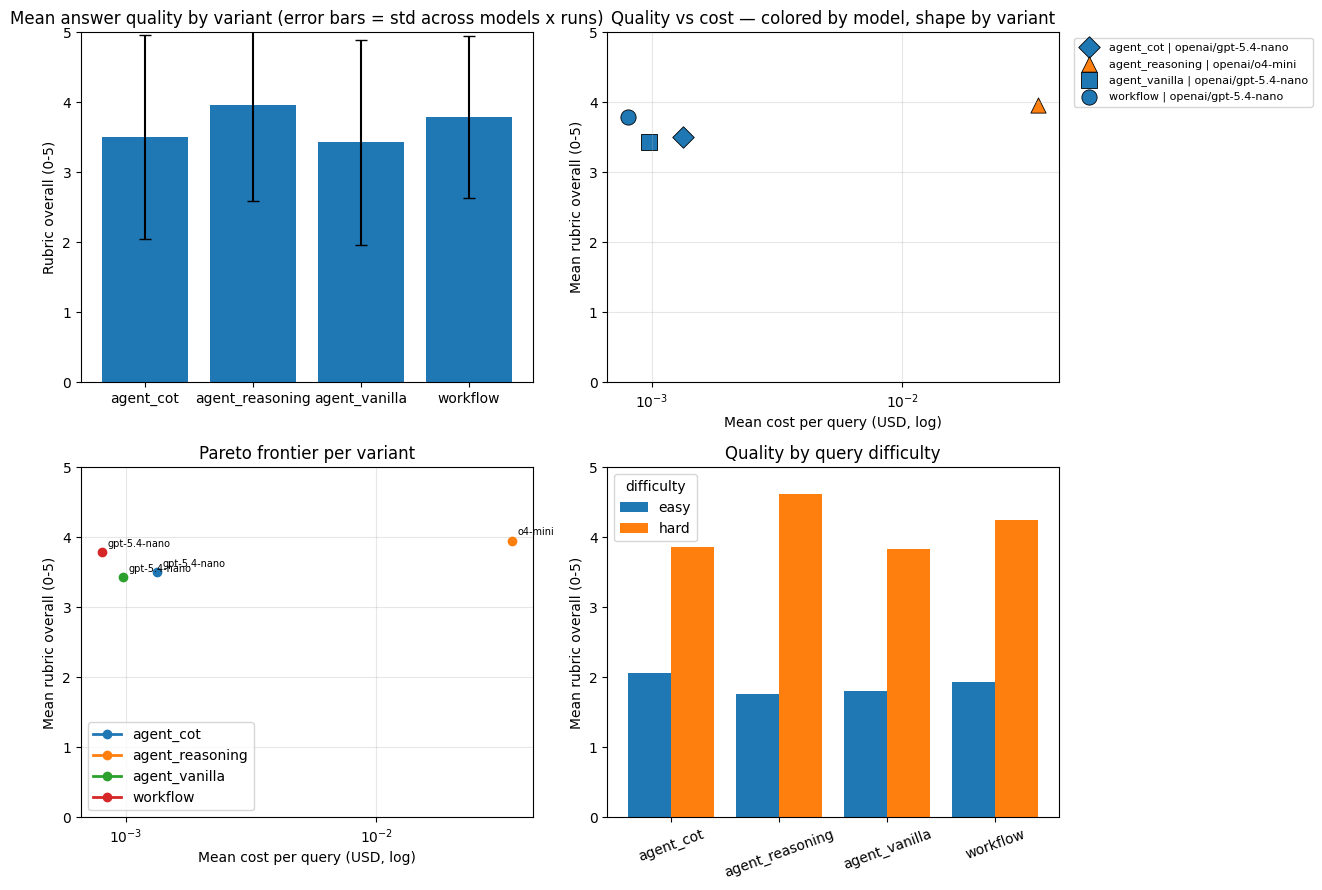

In [13]:
import matplotlib.pyplot as plt

if not df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    plot_overall_bar(df, ax=axes[0][0])
    plot_quality_vs_cost(df, ax=axes[0][1])
    plot_pareto_frontier(df, ax=axes[1][0])
    plot_by_difficulty(df, ax=axes[1][1])
    fig.tight_layout()

## Reading the results — and learning *why* you can't trust them yet

We ran the demo sweep twice on the same code, same gold set, same models. Here is what changed and what didn't between the two runs:

| Variant (model)                  | Quality (run 1 → run 2) | Faithfulness (r1 → r2) | Latency  | Cost    |
|----------------------------------|------------------------:|-----------------------:|---------:|--------:|
| `agent_reasoning` (`o4-mini`)    | 3.99 → **3.96**         | 4.31 → **4.54**        | ~30–46s  | ~$0.020–0.035 |
| `workflow` (`gpt-5.4-nano`)      | 3.11 → **3.79**         | 4.00 → **4.53**        | ~61–70s  | $0.001  |
| `agent_cot` (`gpt-5.4-nano`)     | 3.33 → **3.50**         | 4.13 → **4.27**        | ~5s      | $0.001  |
| `agent_vanilla` (`gpt-5.4-nano`) | 3.62 → **3.43**         | 4.27 → **4.27**        | ~5s      | $0.001  |

**Workflow swung +0.68 points between identical runs. Vanilla swung −0.19. Reasoning model barely moved.**

That is *enormous* run-to-run variance on a 5-point rubric, and it has nothing to do with the model or the scaffold. It comes from three stacked sources of noise: (1) the embedding/rerank pipeline returns slightly different chunks each time you query Chroma, (2) the LLMs themselves sample different tokens at temperature=0 because temperature=0 isn't actually deterministic on most providers, and (3) the LLM judge is itself a stochastic process with its own scoring jitter.

With **n = 5 questions × 3 runs = 15 trajectories per variant**, the standard error of the mean is large enough that any ranking *between scaffolds at the same model* is essentially a coin flip. **This is the most important pedagogical point of the whole capstone:** if you eyeball the means after one demo run and write a tweet thread about which scaffold is best, you are guaranteed to embarrass yourself.

### What the data robustly tells us anyway

Some signals *are* large enough to survive the noise. These are the conclusions you should actually take with you:

1. **Reasoning model is the only thing that consistently moves quality.** `agent_reasoning` (o4-mini) is the top scorer in both runs and the only variant whose quality is clearly separable from the others. Cost: ~20–35× the gpt-5.4-nano variants. **Worth it on hard queries; rounding error on easy ones.** That trade-off is robust and matches the cost-vs-recall pareto curve from the fourth notebook.

2. **Latency and call-count differences are deterministic.** The workflow runs ~6.6 retrievals and takes ~65s no matter the random seed — vs ~2 retrievals and ~5s for vanilla. This is structural and won't average out with more samples. **Workflow is ~13× slower than vanilla; that's the real cost of structure here, not quality.** If you have a latency SLA, that is the constraint that actually matters.

3. **Faithfulness is uniformly high (4.0–4.54) across every variant.** The `evidence=` plumbing we wired through the harness is doing its job. None of these scaffolds is hallucinating; they're all grounding in retrieved chunks. The variance shows up in *correctness* (did the answer match the gold) and *completeness* (did it cover all the facets), not in faithfulness. That is a real and reusable insight: most modern RAG quality differences come from *what you retrieve*, not from how the model uses it.

4. **The workflow's `grade_node` has a known no-op bug.** Read its source comment: it computes per-chunk relevance scores but never actually drops chunks (the LangGraph reducer is append-only; deletions would require a `concat_unique` reducer). So the workflow *pays for grading without filtering on it*, and the synth call sees every chunk every iteration. Even if a future run shows workflow-wins, this is a lurking source of context dilution that's worth fixing before you trust the comparison.

### The honest takeaway

> **At n = 15, you cannot rank scaffolds by quality. Pick on the things that *are* robust: latency, call count, cost, debuggability, and reproducibility. Then run the full 30-question × 3-model × 3-run sweep before you commit to any quality claim.**
>
> What's true today: agentic and workflow scaffolds are *competitive* on quality at the same model size. The frontier-reasoning model is the only reliable quality bump. Add structure when latency tolerates it and your gold set proves it helps; don't add it because it *should* help.

This is also the headline of Anthropic's *Building Effective Agents* — start with the simplest agent loop, measure on your task, add structure only when measurement says you need it. Our two-run swing is a small live demo of why "measure" has to mean *more than one run*.

### What to do next

- **Run the head-to-head cell below** to read actual answer pairs side-by-side. With n=15 we can't trust the means, but we *can* read individual answers and form qualitative hypotheses about *when* each scaffold helps. Use those as candidate hypotheses to test on the full sweep.
- **Run the full sweep** (`DEMO_MODE = False`, ~25–30 min). 30 questions × 3 models × 3 runs = 270 trajectories per variant. That's enough to compute confidence intervals and start trusting the rankings.
- **Fix the `grade_node` bug** as the "Going further" exercise — replace the append-only `evidence` reducer with one that allows the grader to actually drop chunks. Then re-run and see whether workflow's quality firms up.

In [10]:
if not df.empty:
    pivot = df.pivot_table(
        index="query_id", columns="variant", values="overall", aggfunc="mean"
    )
    pivot["spread"] = pivot.max(axis=1) - pivot.min(axis=1)
    print("Top 5 questions where variants disagree the most:")
    display(pivot.sort_values("spread", ascending=False).head(5).round(2))

Top 5 questions where variants disagree the most:


variant,agent_cot,agent_reasoning,agent_vanilla,workflow,spread
query_id,,,,,
hotpot_00,2.40,4.93,2.57,4.09,2.53
single_b1,2.07,1.76,1.80,1.93,0.31
cross_02,3.85,3.60,3.67,3.87,0.27
cross_01,4.20,4.25,4.11,4.07,0.18
hotpot_01,5.00,5.00,5.00,5.00,0.00


In [14]:
# Head-to-head: show actual answers where the gpt-5.4-nano variants disagreed
# most. Holding the model fixed isolates the *structural* effect (workflow vs
# vanilla loop vs CoT prompt) from any model-quality confound.

SAME_MODEL = "openai/gpt-5.4-nano"
ANSWER_PREVIEW_CHARS = 700  # truncate long answers so the side-by-side stays readable

def _show_pairwise(df_in, var_a: str, var_b: str, top_k: int = 1):
    """For each direction (a beats b, b beats a), print the single biggest gap
    found in `df_in` and the actual answers + judge notes side-by-side."""
    sub = df_in[
        (df_in["model"] == SAME_MODEL)
        & (df_in["variant"].isin([var_a, var_b]))
        & (df_in["overall"].notna())
    ]
    # Average over runs first so a single noisy run doesn't dominate.
    pivot = sub.pivot_table(
        index=["query_id", "question"], columns="variant",
        values="overall", aggfunc="mean",
    ).dropna()
    if pivot.empty:
        print(f"(no shared questions between {var_a} and {var_b})")
        return
    pivot["delta_a_minus_b"] = pivot[var_a] - pivot[var_b]

    for direction, sort_asc in [(f"{var_a} BEAT {var_b}", False),
                                (f"{var_b} BEAT {var_a}", True)]:
        winners = pivot.sort_values("delta_a_minus_b", ascending=sort_asc).head(top_k)
        print("=" * 78)
        print(f"  {direction}")
        print("=" * 78)
        for (qid, qtext), row in winners.iterrows():
            print(f"\n[{qid}]  {qtext}")
            print(f"  scores: {var_a}={row[var_a]:.2f}   {var_b}={row[var_b]:.2f}   "
                  f"(delta = {row['delta_a_minus_b']:+.2f})\n")
            for v in [var_a, var_b]:
                rows_v = sub[(sub["query_id"] == qid) & (sub["variant"] == v)]
                if rows_v.empty:
                    continue
                # Pick the run that matches the mean most closely so the printed
                # answer is representative, not a cherry-picked best/worst run.
                target = rows_v["overall"].mean()
                pick = rows_v.iloc[(rows_v["overall"] - target).abs().argsort().iloc[0]]
                ans = (pick["answer"] or "").strip().replace("\n\n", "\n")
                if len(ans) > ANSWER_PREVIEW_CHARS:
                    ans = ans[:ANSWER_PREVIEW_CHARS] + " ... [truncated]"
                print(f"  --- {v} (overall={pick['overall']}, "
                      f"correctness={pick['correctness']}, "
                      f"faithfulness={pick['faithfulness']}) ---")
                print(f"  {ans}")
                if pick.get("judge_notes"):
                    notes = str(pick["judge_notes"]).strip().replace("\n", " ")
                    print(f"  judge: {notes[:300]}")
                print()


print("\n##### vanilla agent vs workflow #####\n")
_show_pairwise(df, "agent_vanilla", "workflow")

print("\n##### vanilla agent vs CoT-prompted agent #####\n")
_show_pairwise(df, "agent_vanilla", "agent_cot")


##### vanilla agent vs workflow #####

  agent_vanilla BEAT workflow

[cross_01]  What does the AI Office Hours post on tool-selection evaluation say about positional bias, and how does that connect to the broader idea of supervised learning evaluation as discussed on Wikipedia?
  scores: agent_vanilla=4.11   workflow=4.07   (delta = +0.04)

  --- agent_vanilla (overall=3.8, correctness=4.0, faithfulness=4.0) ---
  In the **AI Office Hours** post on *tool-selection evaluation*, it warns that **positional bias** can distort results: when tools are placed differently in the agent prompt, the LLM may pay more attention to tools that appear at certain positions (especially the beginning/end) and **under-consider tools in the middle** (“*lost-in-the-middle*”). The post states that if tools later in the list end up in the prompt middle, their information can get **ignored**, and it reports observing that the models **over-select tools in earlier indexes**, with evidence that even strong mod

## Where this goes next

**Week 2** picks up the `gap_analyzer` node from variant A and turns it into a **supervisor** that delegates each sub-query to a specialist research agent. Same loop, multi-agent topology, MCP-mediated tools.

**Week 3** generalizes this `eval_harness` (variants × models × CSV cache + rubric) into the **agent harness** for SWE-bench / GAIA-style benchmarks. Same code, larger task suite.